# **1. Perkenalan Dataset**


# Titanic Survival Prediction Dataset

## Deskripsi Dataset

Dataset Titanic merupakan dataset klasifikasi yang digunakan untuk memprediksi apakah seorang penumpang selamat atau tidak dalam tragedi tenggelamnya kapal Titanic.

Dataset ini berasal dari kompetisi Kaggle Titanic: Machine Learning from Disaster.

## Tujuan Analisis

Melakukan eksplorasi data dan preprocessing sehingga menghasilkan dataset yang siap digunakan pada tahap pelatihan model machine learning.

## Target Variable

- Survived
    - 0 = Tidak Selamat
    - 1 = Selamat

In [2]:
!pip install -q kaggle

In [3]:
mkdir -p ~/.kaggle && echo KGAT_78a435c10905e0a5b39e024b4f2baac7 > ~/.kaggle/access_token && chmod 600 ~/.kaggle/access_token

In [4]:
#Download dataset

!kaggle competitions download -c titanic

100% 34.1k/34.1k [00:00<00:00, 63.0MB/s]



In [5]:
import zipfile

with zipfile.ZipFile("titanic.zip", "r") as zip_ref:
    zip_ref.extractall("titanic_data")

In [6]:
import os

os.listdir("titanic_data")

['test.csv', 'gender_submission.csv', 'train.csv']

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [7]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [8]:
df = pd.read_csv('/content/titanic_data/train.csv')

In [9]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [10]:
print("Jumlah Baris :", df.shape[0])
print("Jumlah Kolom :", df.shape[1])

Jumlah Baris : 891
Jumlah Kolom : 12


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [12]:
# Statistik Deskriptif

df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [13]:
# Missing value

df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


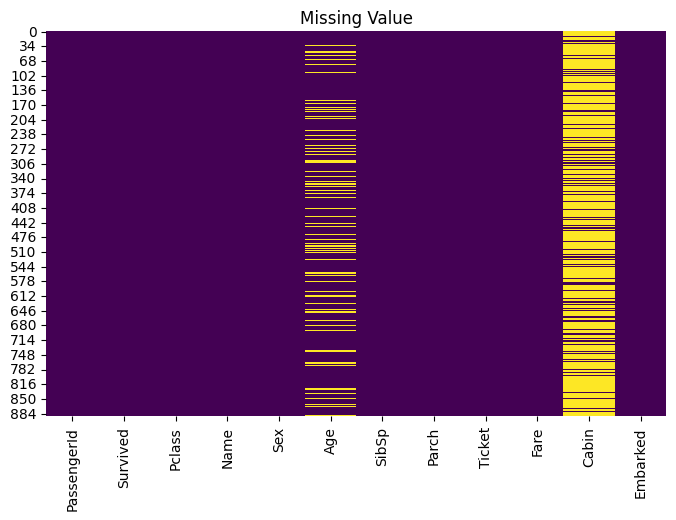

In [14]:
# Visualisasi Missing Value

plt.figure(figsize=(8,5))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap='viridis'
)

plt.title("Missing Value")
plt.show()

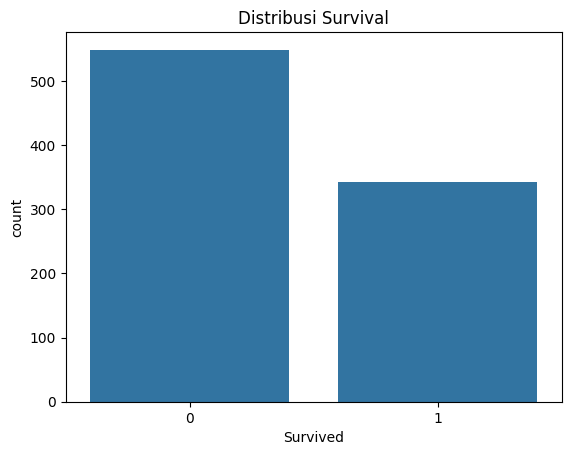

In [15]:
# Distribusi Target

sns.countplot(
    x='Survived',
    data=df
)

plt.title("Distribusi Survival")
plt.show()

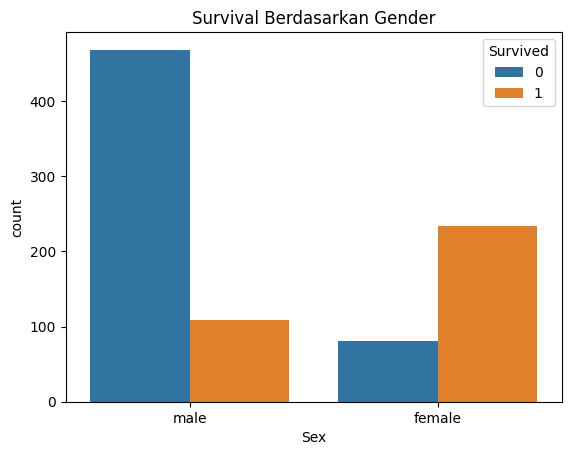

In [16]:
# Survival Berdasarkan Gender

sns.countplot(
    x='Sex',
    hue='Survived',
    data=df
)

plt.title("Survival Berdasarkan Gender")
plt.show()

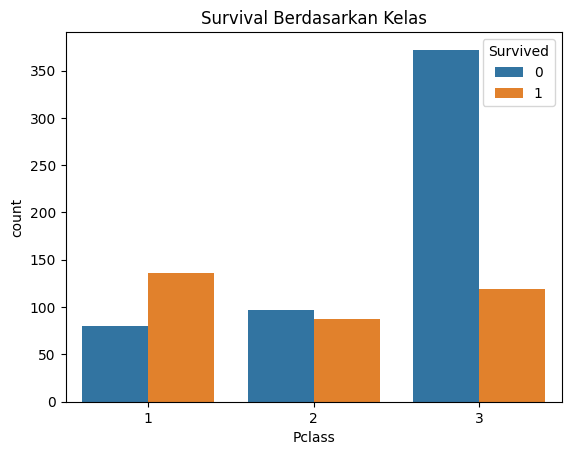

In [17]:
# Survival Berdasarkan Passenger Class

sns.countplot(
    x='Pclass',
    hue='Survived',
    data=df
)

plt.title("Survival Berdasarkan Kelas")
plt.show()

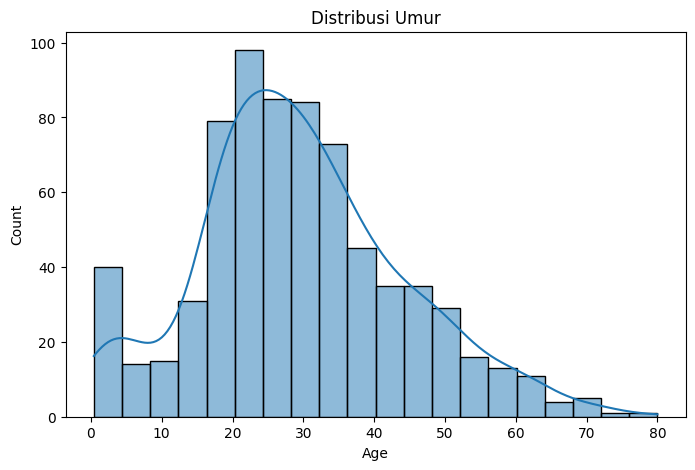

In [18]:
# Distribusi Umur

plt.figure(figsize=(8,5))

sns.histplot(
    df['Age'],
    kde=True
)

plt.title("Distribusi Umur")
plt.show()

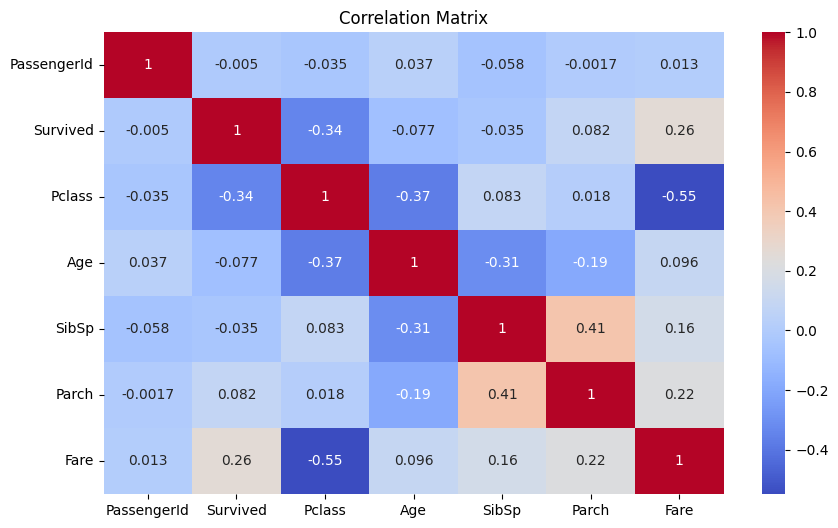

In [19]:
# Korelasi Numerik

numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [20]:
# Copy dataset

data = df.copy()

In [21]:
# Drop kolom tidak relevan

data.drop(
    columns=[
        'PassengerId',
        'Name',
        'Ticket',
        'Cabin'
    ],
    inplace=True
)

In [22]:
# Missing value age

data['Age'] = data['Age'].fillna(
    data['Age'].median()
)

In [23]:
# Missing value embarked

data['Embarked'] = data['Embarked'].fillna(
    data['Embarked'].mode()[0]
)

In [24]:
# Cek ulang missing value

data.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


# Encoding

In [25]:
# Sex

le = LabelEncoder()

data['Sex'] = le.fit_transform(
    data['Sex']
)

In [26]:
# Embarked

data['Embarked'] = le.fit_transform(
    data['Embarked']
)

In [27]:
# Hasil Encoding

data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


# Feature and Target

In [28]:
X = data.drop(
    columns='Survived'
)

y = data['Survived']

# Scaling

In [29]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [30]:
# Dataset setelah scaling

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

X_scaled.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0.827377,0.737695,-0.565736,0.432793,-0.473674,-0.502445,0.585954
1,-1.566107,-1.355574,0.663861,0.432793,-0.473674,0.786845,-1.942303
2,0.827377,-1.355574,-0.258337,-0.474545,-0.473674,-0.488854,0.585954
3,-1.566107,-1.355574,0.433312,0.432793,-0.473674,0.420730,0.585954
4,0.827377,0.737695,0.433312,-0.474545,-0.473674,-0.486337,0.585954


# Dataset Final

In [31]:
processed_df = X_scaled.copy()

processed_df['Survived'] = y

In [32]:
# Cek dataset final

processed_df.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Survived
0,0.827377,0.737695,-0.565736,0.432793,-0.473674,-0.502445,0.585954,0
1,-1.566107,-1.355574,0.663861,0.432793,-0.473674,0.786845,-1.942303,1
2,0.827377,-1.355574,-0.258337,-0.474545,-0.473674,-0.488854,0.585954,1
3,-1.566107,-1.355574,0.433312,0.432793,-0.473674,0.420730,0.585954,1
4,0.827377,0.737695,0.433312,-0.474545,-0.473674,-0.486337,0.585954,0


In [33]:
processed_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    891 non-null    float64
 1   Sex       891 non-null    float64
 2   Age       891 non-null    float64
 3   SibSp     891 non-null    float64
 4   Parch     891 non-null    float64
 5   Fare      891 non-null    float64
 6   Embarked  891 non-null    float64
 7   Survived  891 non-null    int64  
dtypes: float64(7), int64(1)
memory usage: 55.8 KB


# Simpan dataset hasil preprocessing

In [34]:
processed_df.to_csv(
    'titanic_preprocessed.csv',
    index=False
)

In [35]:
# Verifikasi file

os.path.exists(
    'titanic_preprocessed.csv'
)

True

# Download Dataset Preprocessing

In [36]:
from google.colab import files

files.download(
    'titanic_preprocessed.csv'
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>